# Section 2 paper outputs: data and deseasonalization

This notebook generates paper-ready figures and tables for Section 2 using common plotting conventions.

In [3]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start=None):
    path = Path.cwd() if start is None else Path(start)
    for candidate in [path, *path.parents]:
        if (candidate / "AGENTS.md").exists():
            return candidate
    raise RuntimeError("Could not locate repository root")

ROOT = find_repo_root()
PAPER = ROOT / "newpaper"
DATA_DIR = PAPER / "data"
FIG_DIR = PAPER / "figures" / "deseasonalization"
TABLE_DIR = PAPER / "tables" / "deseasonalization"

for directory in [DATA_DIR, FIG_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## German day-ahead price window

The long price window is used to motivate the 2023--2025 calibration sample. The figure is generated from a local cache when available; otherwise the DE--LU hourly day-ahead prices are queried from ENTSO-E and cached under `newpaper/data/`.

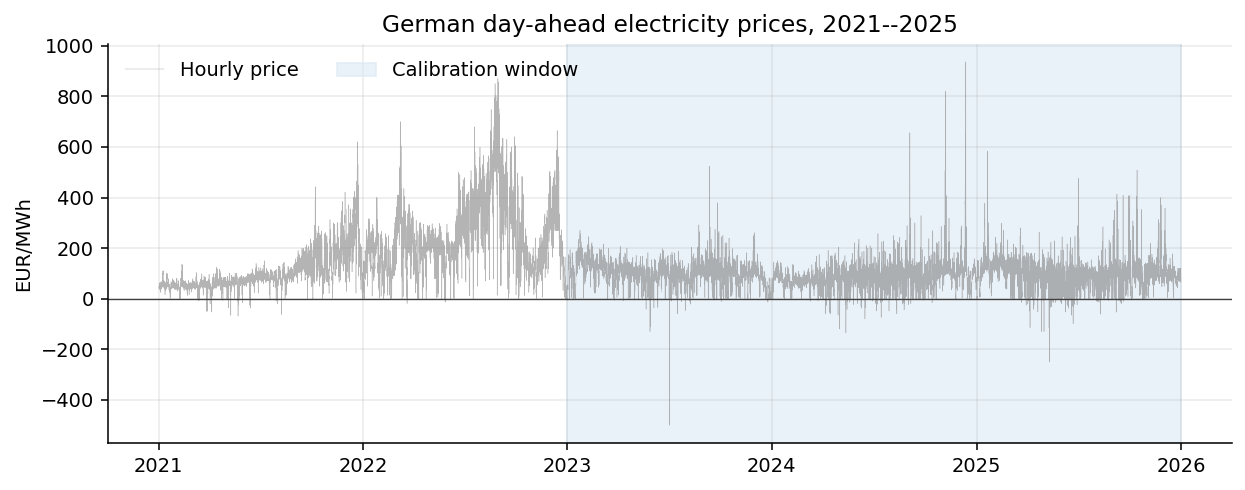

,count,mean,std,min,25%,50%,75%,max
price_eur_mwh,50451.0,115.638889,95.761794,-500.0,67.83,94.07,131.41,936.28


In [4]:
from entsoe import EntsoePandasClient

CACHE = DATA_DIR / "germany_day_ahead_prices_2018_2025.csv"
ZONE = "DE_LU"
PLOT_START = pd.Timestamp("2021-01-01", tz="UTC")
END_EXCLUSIVE = pd.Timestamp("2026-01-01", tz="UTC")

def load_env_api_key():
    if os.getenv("ENTSOE_API_KEY"):
        return os.getenv("ENTSOE_API_KEY")
    env_path = ROOT / ".env"
    if env_path.exists():
        for line in env_path.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if line.startswith("ENTSOE_API_KEY="):
                return line.split("=", 1)[1].strip().strip('"').strip("'")
    return None

def query_entsoe_prices():
    api_key = load_env_api_key()
    if not api_key:
        raise RuntimeError("ENTSOE_API_KEY not found in environment or .env")
    client = EntsoePandasClient(api_key=api_key)
    chunks = []
    for year in range(2018, 2026):
        start = pd.Timestamp(f"{year}-01-01", tz="UTC")
        end = pd.Timestamp(f"{year + 1}-01-01", tz="UTC")
        series = client.query_day_ahead_prices(ZONE, start=start, end=end)
        chunks.append(series.rename("price_eur_mwh"))
    prices = pd.concat(chunks).sort_index()
    prices = prices[~prices.index.duplicated(keep="first")]
    prices.index = prices.index.tz_convert("UTC")
    return prices

if CACHE.exists():
    price = pd.read_csv(CACHE, parse_dates=["datetime"]).set_index("datetime")["price_eur_mwh"]
    price.index = pd.DatetimeIndex(price.index)
    if price.index.tz is None:
        price.index = price.index.tz_localize("UTC")
    else:
        price.index = price.index.tz_convert("UTC")
else:
    price = query_entsoe_prices()
    price.to_frame().rename_axis("datetime").to_csv(CACHE)

price = price.sort_index().loc[PLOT_START:END_EXCLUSIVE - pd.Timedelta(hours=1)]
fig, ax = plt.subplots(figsize=(9.0, 3.0))
ax.plot(price.index, price.values, color="black", linewidth=0.25, alpha=0.55, label="Hourly price")
ax.axvspan(pd.Timestamp("2023-01-01", tz="UTC"), pd.Timestamp("2026-01-01", tz="UTC"), color="steelblue", alpha=0.12, label="Calibration window")
ax.axhline(0.0, color="0.25", linewidth=0.7)
ax.set_title("German day-ahead electricity prices, 2021--2025")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("")
ax.legend(loc="upper left", frameon=False, ncol=2)
fig.tight_layout()

for ext in ["pdf", "png"]:
    fig.savefig(FIG_DIR / f"price_window_2021_2025.{ext}", bbox_inches="tight")

display(fig)
plt.close(fig)

price.describe().to_frame("price_eur_mwh").T

## Price seasonal fit and marginal distributions

The seasonal fit is shown in the transformed log-price coordinate, which is the coordinate used by the deseasonalization model. The distribution panel compares the raw shifted log-price with the fitted deterministic component.

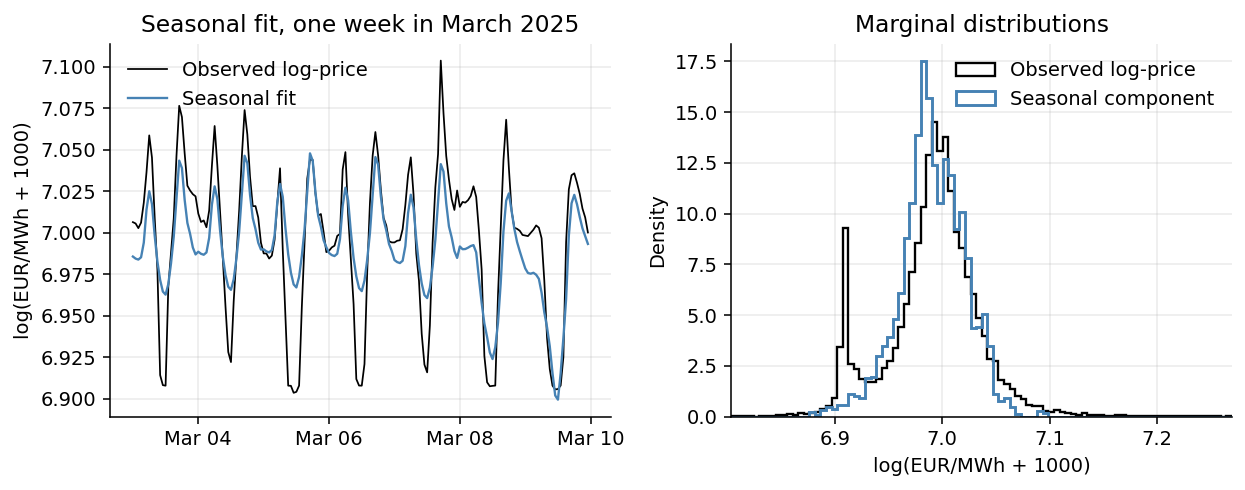

n_log_price       26305
n_log_seasonal    26305
dtype: int64

In [9]:
import matplotlib.dates as mdates
import numpy as np

PANEL_PATH = ROOT / "germany" / "germany23+24+25" / "data" / "seasonality" / "german_panel.csv"
panel = pd.read_csv(PANEL_PATH, parse_dates=["datetime"]).set_index("datetime")
panel.index = pd.DatetimeIndex(panel.index)
if panel.index.tz is None:
    panel.index = panel.index.tz_localize("UTC")
else:
    panel.index = panel.index.tz_convert("UTC")

week_start = pd.Timestamp("2025-03-03", tz="UTC")
week_end = week_start + pd.Timedelta(days=7)
week = panel.loc[(panel.index >= week_start) & (panel.index < week_end)]
log_price = panel["log_price"].replace([np.inf, -np.inf], np.nan).dropna()
log_seasonal = panel["log_price_seasonal"].replace([np.inf, -np.inf], np.nan).dropna()
q_low = min(log_price.quantile(0.001), log_seasonal.quantile(0.001))
q_high = max(log_price.quantile(0.999), log_seasonal.quantile(0.999))

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0))

axes[0].plot(week.index, week["log_price"], color="black", linewidth=0.9, label="Observed log-price")
axes[0].plot(week.index, week["log_price_seasonal"], color="steelblue", linewidth=1.2, label="Seasonal fit")
axes[0].set_title("Seasonal fit, one week in March 2025")
axes[0].set_ylabel("log(EUR/MWh + 1000)")
axes[0].set_xlabel("")
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0].legend(frameon=False, loc="upper left")

axes[1].hist(log_price, bins=90, range=(q_low, q_high), density=True, histtype="step", linewidth=1.2, color="black", label="Observed log-price")
axes[1].hist(log_seasonal, bins=90, range=(q_low, q_high), density=True, histtype="step", linewidth=1.5, color="steelblue", label="Seasonal component")
axes[1].set_title("Marginal distributions")
axes[1].set_xlabel("log(EUR/MWh + 1000)")
axes[1].set_ylabel("Density")
axes[1].set_xlim(q_low, q_high)
axes[1].legend(frameon=False, loc="upper right")

fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIG_DIR / f"price_seasonal_fit_distribution.{ext}", bbox_inches="tight")
display(fig)
plt.close(fig)

pd.Series({"n_log_price": len(log_price), "n_log_seasonal": len(log_seasonal)})

## Price ACF before and after deseasonalization

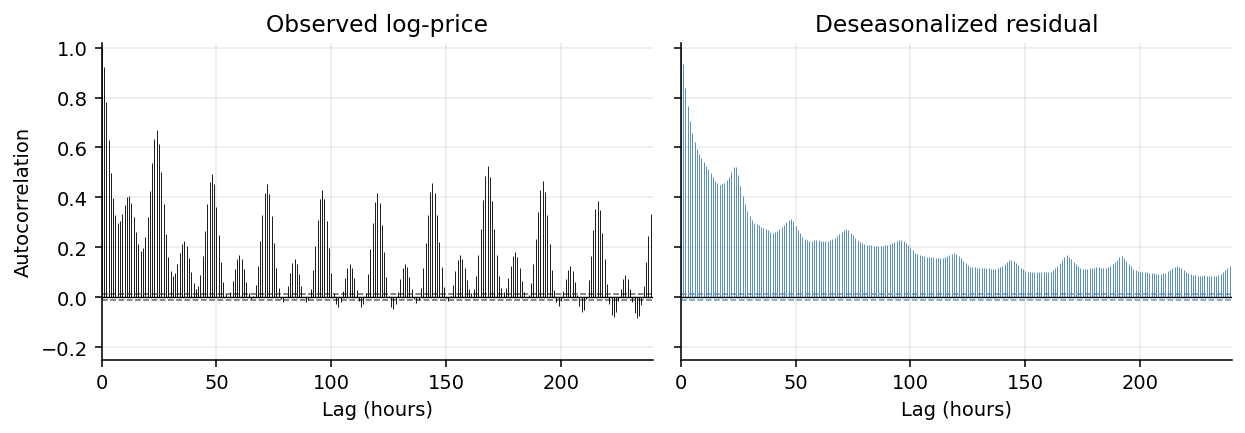

In [8]:
from statsmodels.tsa.stattools import acf

LAGS = 240
raw_acf_series = panel["log_price"].replace([np.inf, -np.inf], np.nan).dropna()
resid_acf_series = panel["log_price_resid"].replace([np.inf, -np.inf], np.nan).dropna()

acf_raw = acf(raw_acf_series, nlags=LAGS, fft=True)
acf_resid = acf(resid_acf_series, nlags=LAGS, fft=True)
lags = np.arange(LAGS + 1)
conf_raw = 1.96 / np.sqrt(len(raw_acf_series))
conf_resid = 1.96 / np.sqrt(len(resid_acf_series))

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0), sharey=True)

axes[0].vlines(lags, 0.0, acf_raw, color="black", linewidth=0.45)
axes[0].axhline(0.0, color="black", linewidth=0.7)
axes[0].axhline(conf_raw, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].axhline(-conf_raw, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].set_title("Observed log-price")
axes[0].set_xlabel("Lag (hours)")
axes[0].set_ylabel("Autocorrelation")

axes[1].vlines(lags, 0.0, acf_resid, color="steelblue", linewidth=0.45)
axes[1].axhline(0.0, color="black", linewidth=0.7)
axes[1].axhline(conf_resid, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.8)
axes[1].axhline(-conf_resid, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.8)
axes[1].set_title("Deseasonalized residual")
axes[1].set_xlabel("Lag (hours)")

for ax in axes:
    ax.set_xlim(0, LAGS)
    ax.set_ylim(-0.25, 1.02)

fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIG_DIR / f"price_acf_before_after_240.{ext}", bbox_inches="tight")
display(fig)
plt.close(fig)

## Temperature seasonal fit and distribution

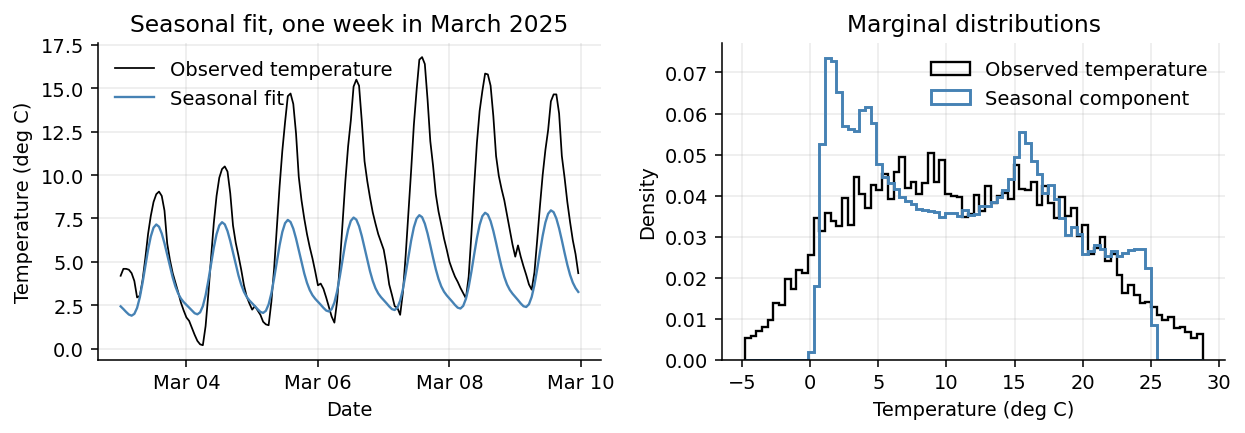

n_temperature             26304
n_temperature_seasonal    26304
dtype: int64

In [10]:
temp = panel[["temp_raw", "temp_seasonal", "temp_resid"]].replace([np.inf, -np.inf], np.nan).dropna()

week_start = pd.Timestamp("2025-03-03", tz="UTC")
week_end = week_start + pd.Timedelta(days=7)
week = temp.loc[(temp.index >= week_start) & (temp.index < week_end)]

temp_raw = temp["temp_raw"]
temp_seasonal = temp["temp_seasonal"]
q_low, q_high = pd.concat([temp_raw, temp_seasonal]).quantile([0.005, 0.995])

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0))

axes[0].plot(week.index, week["temp_raw"], color="black", linewidth=0.9, label="Observed temperature")
axes[0].plot(week.index, week["temp_seasonal"], color="steelblue", linewidth=1.2, label="Seasonal fit")
axes[0].set_title("Seasonal fit, one week in March 2025")
axes[0].set_ylabel("Temperature (deg C)")
axes[0].set_xlabel("Date")
axes[0].legend(frameon=False, loc="best")
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

axes[1].hist(temp_raw, bins=80, range=(q_low, q_high), density=True, histtype="step", linewidth=1.2, color="black", label="Observed temperature")
axes[1].hist(temp_seasonal, bins=80, range=(q_low, q_high), density=True, histtype="step", linewidth=1.5, color="steelblue", label="Seasonal component")
axes[1].set_title("Marginal distributions")
axes[1].set_xlabel("Temperature (deg C)")
axes[1].set_ylabel("Density")
axes[1].legend(frameon=False, loc="best")

fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIG_DIR / f"temperature_seasonal_fit_distribution.{ext}", bbox_inches="tight")
display(fig)
plt.close(fig)

pd.Series({"n_temperature": len(temp_raw), "n_temperature_seasonal": len(temp_seasonal)})

## Temperature ACF before and after deseasonalization

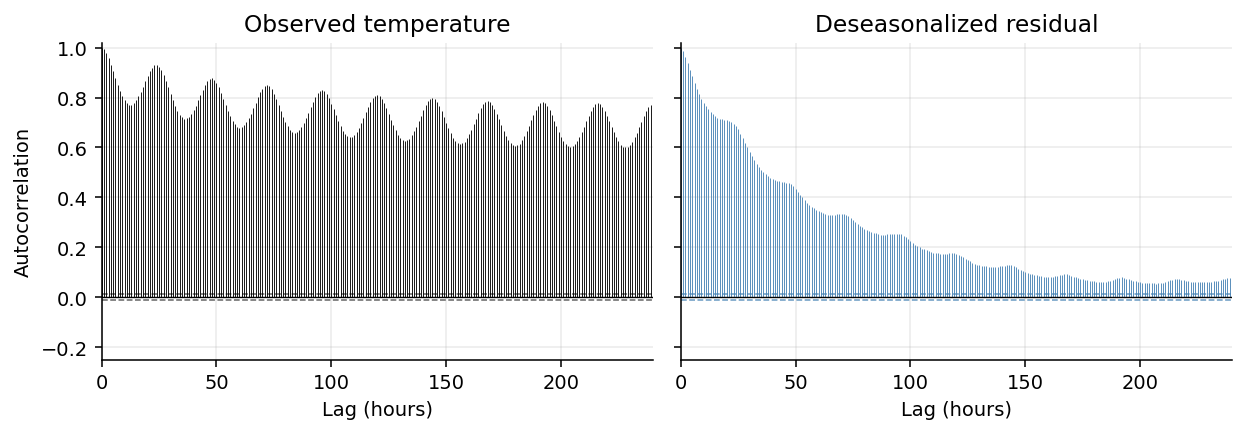

In [11]:
LAGS = 240
raw_acf_series = temp["temp_raw"].replace([np.inf, -np.inf], np.nan).dropna()
resid_acf_series = temp["temp_resid"].replace([np.inf, -np.inf], np.nan).dropna()

acf_raw = acf(raw_acf_series, nlags=LAGS, fft=True)
acf_resid = acf(resid_acf_series, nlags=LAGS, fft=True)
lags = np.arange(LAGS + 1)
conf_raw = 1.96 / np.sqrt(len(raw_acf_series))
conf_resid = 1.96 / np.sqrt(len(resid_acf_series))

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0), sharey=True)

axes[0].vlines(lags, 0.0, acf_raw, color="black", linewidth=0.45)
axes[0].axhline(0.0, color="black", linewidth=0.7)
axes[0].axhline(conf_raw, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].axhline(-conf_raw, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].set_title("Observed temperature")
axes[0].set_xlabel("Lag (hours)")
axes[0].set_ylabel("Autocorrelation")

axes[1].vlines(lags, 0.0, acf_resid, color="steelblue", linewidth=0.45)
axes[1].axhline(0.0, color="black", linewidth=0.7)
axes[1].axhline(conf_resid, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.8)
axes[1].axhline(-conf_resid, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.8)
axes[1].set_title("Deseasonalized residual")
axes[1].set_xlabel("Lag (hours)")

for ax in axes:
    ax.set_xlim(0, LAGS)
    ax.set_ylim(-0.25, 1.02)

fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIG_DIR / f"temperature_acf_before_after_240.{ext}", bbox_inches="tight")
display(fig)
plt.close(fig)

## Solar raw data and transformation steps

These cells generate paper figures that show the raw solar capacity factor and the main clear-sky transformation steps.

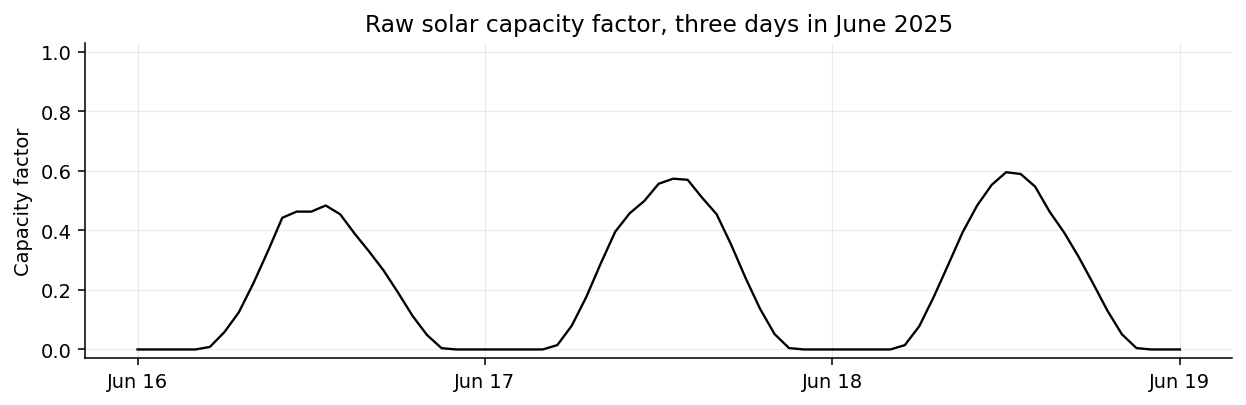

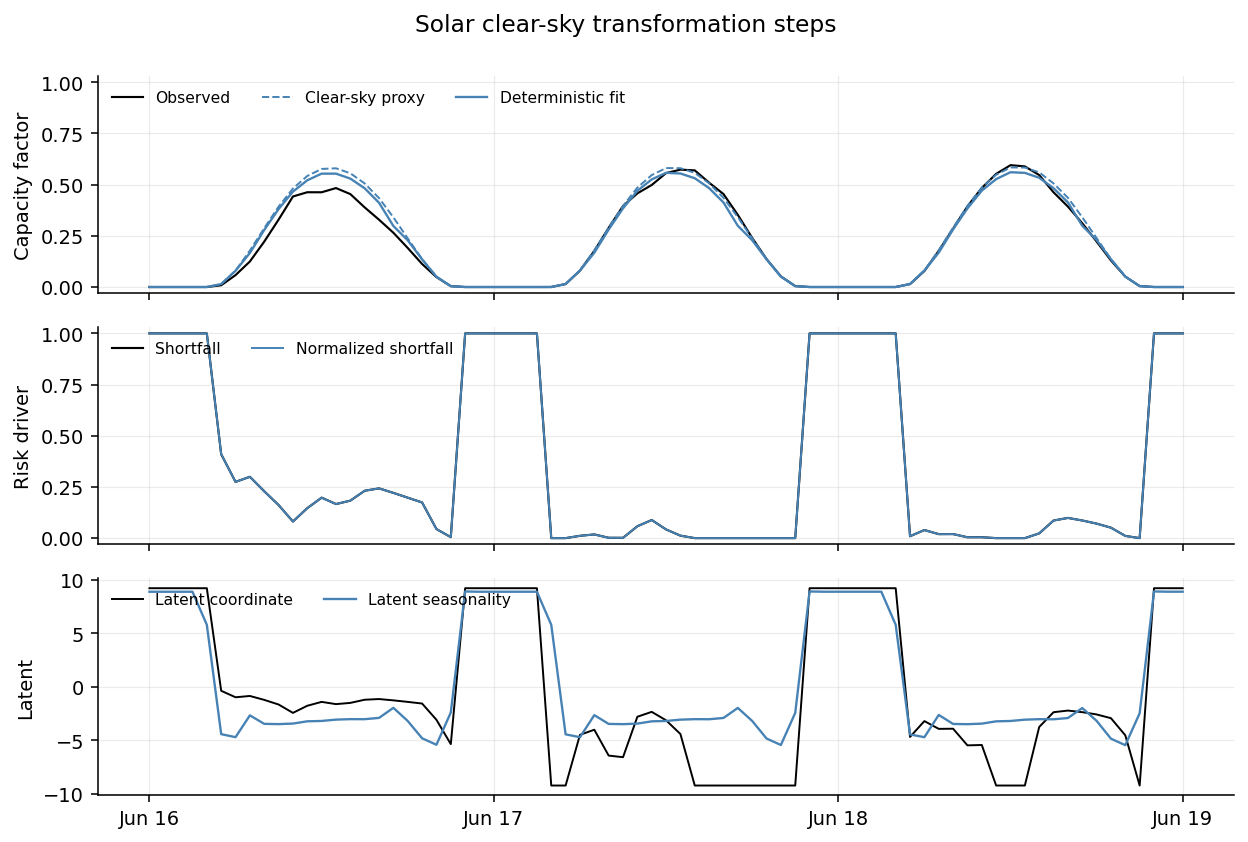

In [14]:
import matplotlib.dates as mdates
import numpy as np

BLACK = "black"
BLUE = "steelblue"
FIGSIZE = (9.0, 3.0)

solar = pd.read_csv(
    ROOT / "solar" / "Intensity_Model_solar" / "data" / "carma" / "solar_latent_panel.csv",
    index_col=0,
    parse_dates=True,
)
solar.index = pd.DatetimeIndex(solar.index)
if solar.index.tz is None:
    solar.index = solar.index.tz_localize("UTC")
else:
    solar.index = solar.index.tz_convert("UTC")

alpha = 1e-4
beta = 0.9998
sigmoid_seasonal = 1.0 / (1.0 + np.exp(-solar["solar_latent_seasonality"]))
solar["solar_seasonality_cf_scale"] = (
    solar["solar_clear_sky"] * (1.0 - alpha - beta * sigmoid_seasonal)
).clip(0.0, 1.0)

raw_window = solar.loc[
    pd.Timestamp("2025-06-16", tz="UTC"):pd.Timestamp("2025-06-19", tz="UTC")
]
steps_window = solar.loc[
    pd.Timestamp("2025-06-16", tz="UTC"):pd.Timestamp("2025-06-23", tz="UTC")
]

def style_axes(ax, day_interval=1):
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=day_interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

def save_figure(fig, stem):
    for ext in ["pdf", "png"]:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight")

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(raw_window.index, raw_window["solar_cf"], color=BLACK, linewidth=1.2)
ax.set_title("Raw solar capacity factor, three days in June 2025")
ax.set_ylabel("Capacity factor")
ax.set_xlabel("")
ax.set_ylim(-0.03, 1.03)
style_axes(ax)
fig.tight_layout()
save_figure(fig, "solar_raw_three_days")
display(fig)
plt.close(fig)

fig, axes = plt.subplots(3, 1, figsize=(9.0, 6.0), sharex=True)
axes[0].plot(steps_window.index, steps_window["solar_cf"], color=BLACK, linewidth=0.95, label="Observed CF")
axes[0].plot(steps_window.index, steps_window["solar_clear_sky"], color=BLUE, linewidth=0.9, linestyle="--", label="Clear-sky proxy")
axes[0].plot(steps_window.index, steps_window["solar_seasonality_cf_scale"], color=BLUE, linewidth=1.15, label="Latent seasonality in CF scale")
axes[0].set_ylabel("Capacity factor")
axes[0].set_ylim(-0.03, 1.03)
axes[0].legend(frameon=False, ncol=3, fontsize=8, loc="upper left")

axes[1].plot(steps_window.index, steps_window["solar_risk_driver"], color=BLACK, linewidth=0.95, label="Shortfall")
axes[1].plot(steps_window.index, steps_window["solar_xprime"], color=BLUE, linewidth=0.95, label="Normalized shortfall")
axes[1].set_ylabel("Risk driver")
axes[1].set_ylim(-0.03, 1.03)
axes[1].legend(frameon=False, ncol=2, fontsize=8, loc="upper left")

axes[2].plot(steps_window.index, steps_window["solar_latent_Y"], color=BLACK, linewidth=0.9, label="Latent coordinate")
axes[2].plot(steps_window.index, steps_window["solar_latent_seasonality"], color=BLUE, linewidth=1.1, label="Latent seasonality")
axes[2].set_ylabel("Latent")
axes[2].legend(frameon=False, ncol=2, fontsize=8, loc="upper left")

for ax in axes:
    style_axes(ax, day_interval=2)
fig.suptitle("Solar clear-sky transformation, one week in June 2025", y=0.995)
fig.tight_layout()
save_figure(fig, "solar_transformation_steps")
display(fig)
plt.close(fig)

## Solar clear-sky fit and latent distribution

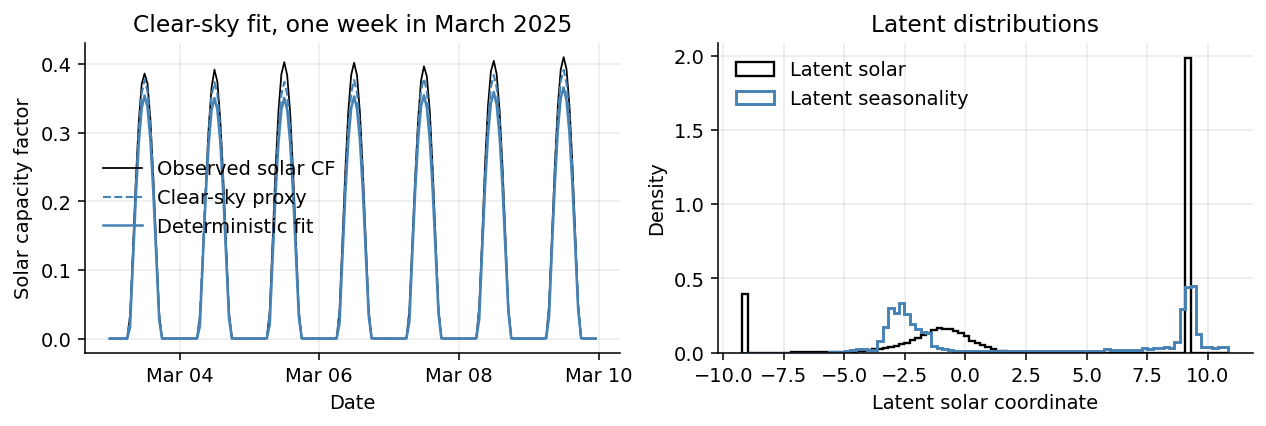

n_solar     40627
n_latent    40627
dtype: int64

In [15]:
solar_panel_path = ROOT / "solar" / "Intensity_Model_solar" / "data" / "carma" / "solar_latent_panel.csv"
solar = pd.read_csv(solar_panel_path, index_col=0, parse_dates=True).sort_index()
if solar.index.tz is None:
    solar.index = solar.index.tz_localize("UTC")
else:
    solar.index = solar.index.tz_convert("UTC")

alpha = 0.0001
beta = 0.9998
sigmoid_seasonal = 1.0 / (1.0 + np.exp(-solar["solar_latent_seasonality"]))
solar["solar_physical_fit"] = (solar["solar_clear_sky"] * (1.0 - alpha - beta * sigmoid_seasonal)).clip(0.0, 1.0)

week_start = pd.Timestamp("2025-03-03", tz="UTC")
week_end = week_start + pd.Timedelta(days=7)
week = solar.loc[(solar.index >= week_start) & (solar.index < week_end)]

latent_raw = solar["solar_latent_Y"].replace([np.inf, -np.inf], np.nan).dropna()
latent_seasonal = solar["solar_latent_seasonality"].replace([np.inf, -np.inf], np.nan).dropna()
q_low, q_high = pd.concat([latent_raw, latent_seasonal]).quantile([0.005, 0.995])

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0))

axes[0].plot(week.index, week["solar_cf"], color="black", linewidth=0.9, label="Observed solar CF")
axes[0].plot(week.index, week["solar_clear_sky"], color="steelblue", linestyle="--", linewidth=1.1, label="Clear-sky proxy")
axes[0].plot(week.index, week["solar_physical_fit"], color="steelblue", linewidth=1.3, label="Deterministic fit")
axes[0].set_title("Clear-sky fit, one week in March 2025")
axes[0].set_ylabel("Solar capacity factor")
axes[0].set_xlabel("Date")
axes[0].legend(frameon=False, loc="best")
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

axes[1].hist(latent_raw, bins=90, range=(q_low, q_high), density=True, histtype="step", linewidth=1.2, color="black", label="Latent solar")
axes[1].hist(latent_seasonal, bins=90, range=(q_low, q_high), density=True, histtype="step", linewidth=1.5, color="steelblue", label="Latent seasonality")
axes[1].set_title("Latent distributions")
axes[1].set_xlabel("Latent solar coordinate")
axes[1].set_ylabel("Density")
axes[1].legend(frameon=False, loc="best")

fig.tight_layout(pad=0.55)
for ext in ["pdf", "png"]:
    fig.savefig(FIG_DIR / f"solar_clearsky_fit_distribution.{ext}", bbox_inches="tight")
display(fig)
plt.close(fig)

pd.Series({"n_solar": len(solar), "n_latent": len(latent_raw)})

## Solar latent ACF before and after deseasonalization

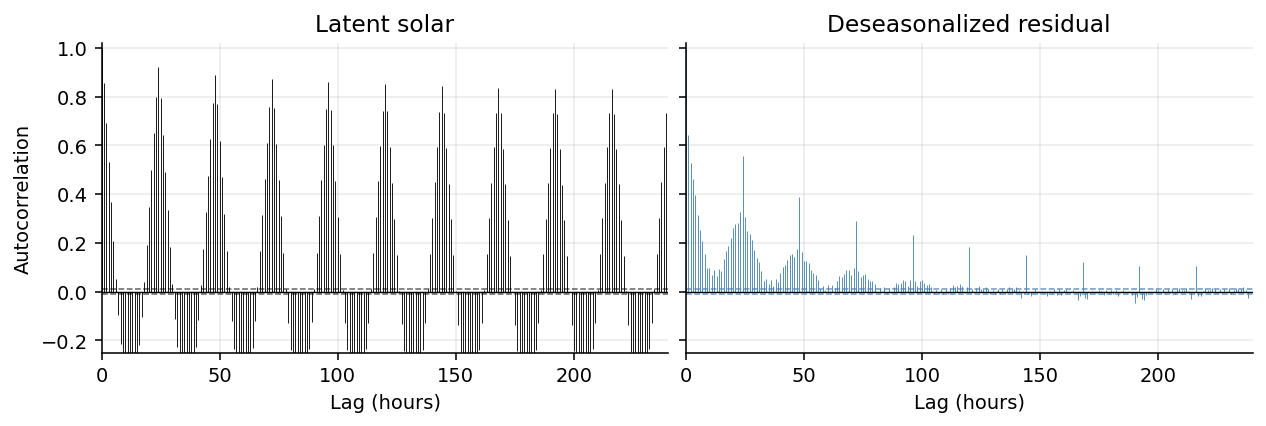

In [16]:
LAGS = 240
raw_acf_series = solar["solar_latent_Y"].replace([np.inf, -np.inf], np.nan).dropna()
resid_acf_series = solar["solar_XtQ"].replace([np.inf, -np.inf], np.nan).dropna()

acf_raw = acf(raw_acf_series, nlags=LAGS, fft=True)
acf_resid = acf(resid_acf_series, nlags=LAGS, fft=True)
lags = np.arange(LAGS + 1)
conf_raw = 1.96 / np.sqrt(len(raw_acf_series))
conf_resid = 1.96 / np.sqrt(len(resid_acf_series))

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0), sharey=True)

axes[0].vlines(lags, 0.0, acf_raw, color="black", linewidth=0.45)
axes[0].axhline(0.0, color="black", linewidth=0.7)
axes[0].axhline(conf_raw, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].axhline(-conf_raw, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].set_title("Latent solar")
axes[0].set_xlabel("Lag (hours)")
axes[0].set_ylabel("Autocorrelation")

axes[1].vlines(lags, 0.0, acf_resid, color="steelblue", linewidth=0.45)
axes[1].axhline(0.0, color="black", linewidth=0.7)
axes[1].axhline(conf_resid, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.8)
axes[1].axhline(-conf_resid, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.8)
axes[1].set_title("Deseasonalized residual")
axes[1].set_xlabel("Lag (hours)")

for ax in axes:
    ax.set_xlim(0, LAGS)
    ax.set_ylim(-0.25, 1.02)

fig.tight_layout(pad=0.55)
for ext in ["pdf", "png"]:
    fig.savefig(FIG_DIR / f"solar_acf_before_after_240.{ext}", bbox_inches="tight")
display(fig)
plt.close(fig)

## Wind raw data and logit transformation steps

These cells generate paper figures for the wind capacity-factor transformation and deseasonalization diagnostics.

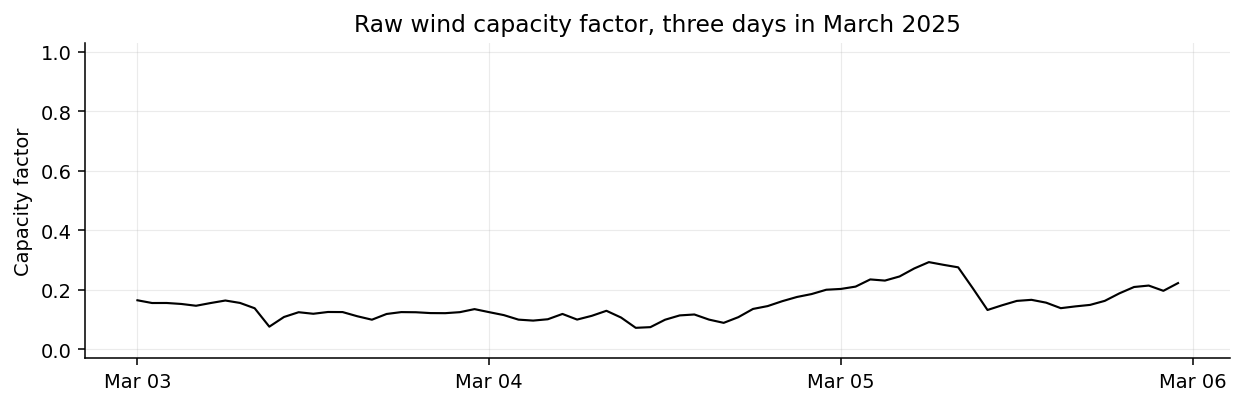

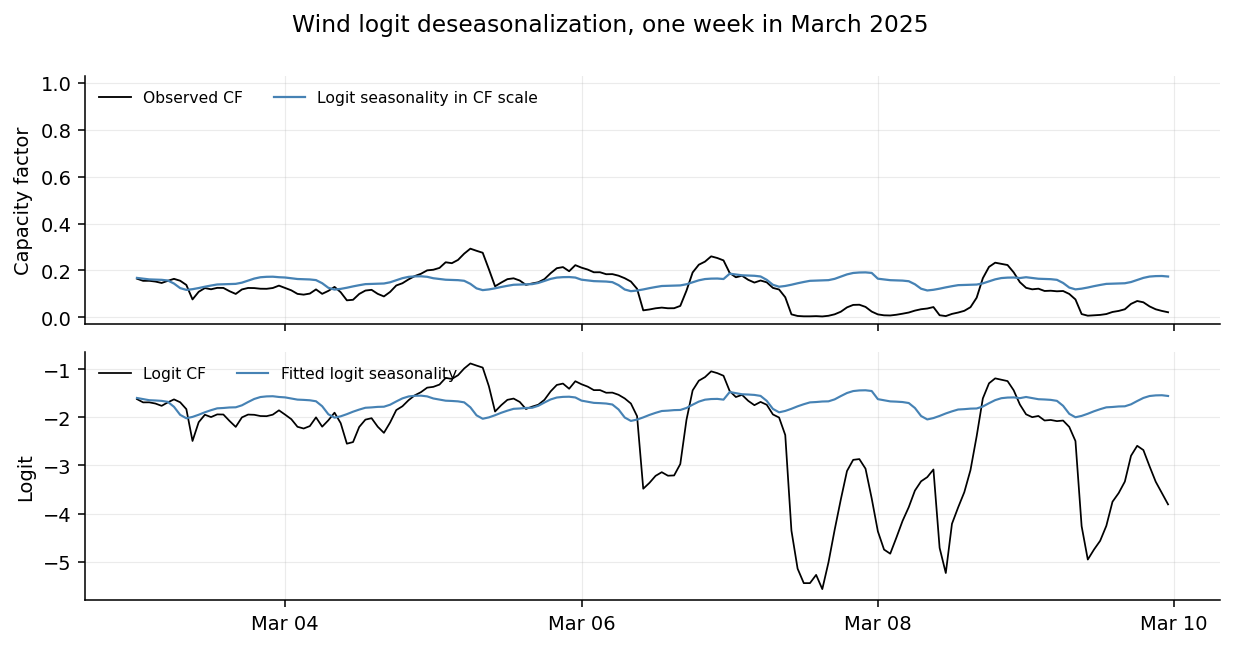

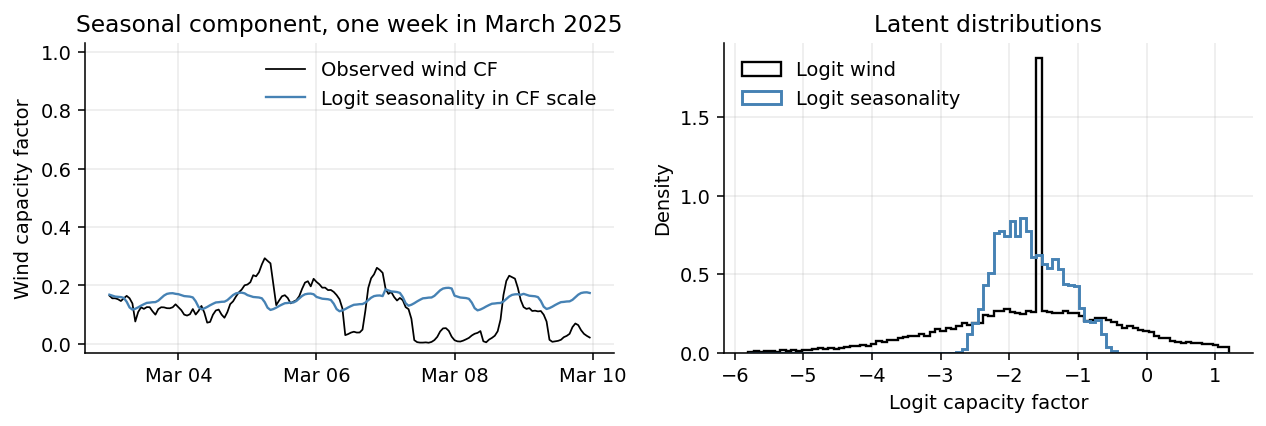

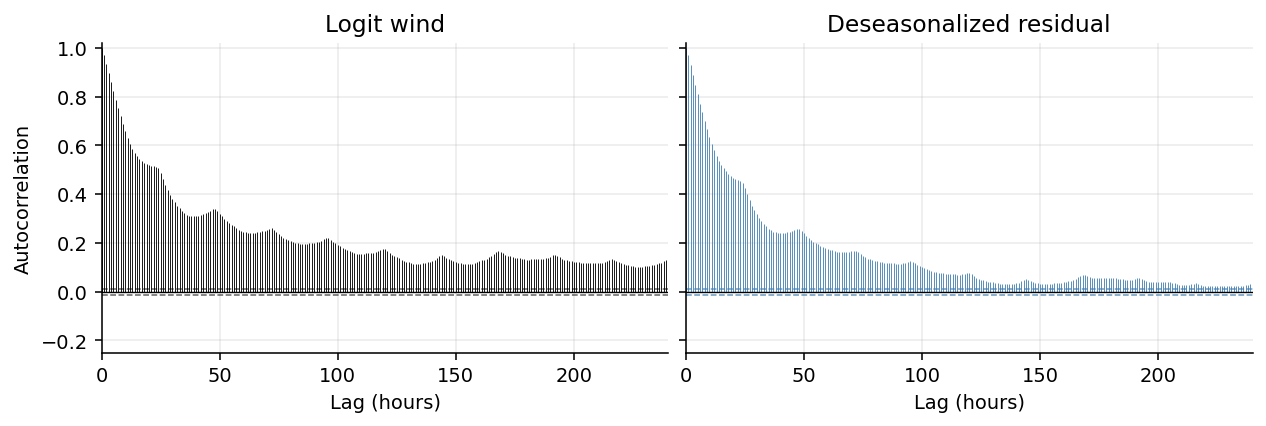

In [18]:
import matplotlib.dates as mdates
import numpy as np
from statsmodels.tsa.stattools import acf

BLACK = "black"
BLUE = "steelblue"
FIGSIZE = (9.0, 3.0)

wind_panel_path = ROOT / "wind" / "carma_coupling" / "data" / "carma" / "wind_latent_panel.csv"
wind = pd.read_csv(wind_panel_path, index_col=0, parse_dates=True).sort_index()
wind.index = pd.DatetimeIndex(wind.index)
if wind.index.tz is None:
    wind.index = wind.index.tz_localize("UTC")
else:
    wind.index = wind.index.tz_convert("UTC")
wind["wind_seasonality_cf_scale"] = 1.0 / (1.0 + np.exp(-wind["wind_logit_seasonality"]))

raw_start = pd.Timestamp("2025-03-03", tz="UTC")
raw_window = wind.loc[(wind.index >= raw_start) & (wind.index < raw_start + pd.Timedelta(days=3))]
steps_window = wind.loc[(wind.index >= raw_start) & (wind.index < raw_start + pd.Timedelta(days=7))]
week = steps_window

def style_axes(ax, day_interval=1):
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=day_interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

def save_figure(fig, stem):
    for ext in ["pdf", "png"]:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight")

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(raw_window.index, raw_window["wind_cf"], color=BLACK, linewidth=1.1)
ax.set_title("Raw wind capacity factor, three days in March 2025")
ax.set_ylabel("Capacity factor")
ax.set_xlabel("")
ax.set_ylim(-0.03, 1.03)
style_axes(ax)
fig.tight_layout()
save_figure(fig, "wind_raw_three_days")
display(fig)
plt.close(fig)

latent_raw = wind["wind_logit"].replace([np.inf, -np.inf], np.nan).dropna()
latent_seasonal = wind["wind_logit_seasonality"].replace([np.inf, -np.inf], np.nan).dropna()
q_low, q_high = pd.concat([latent_raw, latent_seasonal]).quantile([0.005, 0.995])

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].plot(week.index, week["wind_cf"], color=BLACK, linewidth=0.9, label="Observed wind CF")
axes[0].plot(week.index, week["wind_seasonality_cf_scale"], color=BLUE, linewidth=1.2, label="Logit seasonality in CF scale")
axes[0].set_title("Seasonal component, one week in March 2025")
axes[0].set_ylabel("Wind capacity factor")
axes[0].set_xlabel("")
axes[0].set_ylim(-0.03, 1.03)
axes[0].legend(frameon=False, loc="best")
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

axes[1].hist(latent_raw, bins=90, range=(q_low, q_high), density=True, histtype="step", linewidth=1.2, color=BLACK, label="Logit wind")
axes[1].hist(latent_seasonal, bins=90, range=(q_low, q_high), density=True, histtype="step", linewidth=1.5, color=BLUE, label="Logit seasonality")
axes[1].set_title("Latent distributions")
axes[1].set_xlabel("Logit capacity factor")
axes[1].set_ylabel("Density")
axes[1].legend(frameon=False, loc="best")
fig.tight_layout(pad=0.55)
save_figure(fig, "wind_seasonal_fit_distribution")
display(fig)
plt.close(fig)

LAGS = 240
raw_acf_series = wind["wind_logit"].replace([np.inf, -np.inf], np.nan).dropna()
resid_acf_series = wind["wind_XtQ"].replace([np.inf, -np.inf], np.nan).dropna()
acf_raw = acf(raw_acf_series, nlags=LAGS, fft=True)
acf_resid = acf(resid_acf_series, nlags=LAGS, fft=True)
lags = np.arange(LAGS + 1)
conf_raw = 1.96 / np.sqrt(len(raw_acf_series))
conf_resid = 1.96 / np.sqrt(len(resid_acf_series))

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, sharey=True)
axes[0].vlines(lags, 0.0, acf_raw, color=BLACK, linewidth=0.45)
axes[0].axhline(0.0, color=BLACK, linewidth=0.7)
axes[0].axhline(conf_raw, color=BLACK, linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].axhline(-conf_raw, color=BLACK, linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].set_title("Logit wind")
axes[0].set_xlabel("Lag (hours)")
axes[0].set_ylabel("Autocorrelation")

axes[1].vlines(lags, 0.0, acf_resid, color=BLUE, linewidth=0.45)
axes[1].axhline(0.0, color=BLACK, linewidth=0.7)
axes[1].axhline(conf_resid, color=BLUE, linestyle="--", linewidth=0.8, alpha=0.8)
axes[1].axhline(-conf_resid, color=BLUE, linestyle="--", linewidth=0.8, alpha=0.8)
axes[1].set_title("Deseasonalized residual")
axes[1].set_xlabel("Lag (hours)")
for ax in axes:
    ax.set_xlim(0, LAGS)
    ax.set_ylim(-0.25, 1.02)
fig.tight_layout(pad=0.55)
save_figure(fig, "wind_acf_before_after_240")
display(fig)
plt.close(fig)